<h2>Drug Regulatory Risk Classification System </h2>

<h4>Project Goal</h4>

<h4>Step 1: Import Libraries</h4>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import warnings
warnings.filterwarnings("ignore")

<h4>Step 2: Load Dataset</h4>

In [5]:
data = pd.read_csv(r"C:\Users\manoh\Downloads\drug_regulatory_classification_dataset.csv")
data

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Manufacturing_Region,Requires_Cold_Storage,OTC_Flag,High_Risk_Substance,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate,Target_Regulatory_Class
0,250,364.22,246.49,159132.53,3,4.26,2.52,0.74,57.93,42.07,...,South,No,No,No,64.46,41.88,41.15,6.56,0.47,Non-Regulated Drug
1,500,112.86,73.22,260595.45,2,8.12,1.80,0.48,48.00,52.00,...,East,Yes,Yes,No,93.37,10.30,50.05,4.01,0.44,Non-Regulated Drug
2,200,197.24,100.72,106818.45,3,1.58,1.47,0.93,54.48,45.52,...,North,Yes,Yes,No,64.53,34.21,46.42,5.95,0.16,Non-Regulated Drug
3,500,373.55,264.76,231304.59,4,1.72,1.61,0.54,47.20,52.80,...,North,No,Yes,No,95.21,71.04,49.52,9.65,0.76,Non-Regulated Drug
4,500,353.87,277.29,319403.02,2,9.64,0.45,0.50,86.96,13.04,...,North,No,Yes,No,98.05,70.28,44.90,1.79,0.36,Non-Regulated Drug
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,200,260.68,167.61,337160.40,2,6.04,2.79,0.92,67.01,32.99,...,East,Yes,No,No,60.31,73.67,25.44,2.97,0.95,Regulated Drug
59996,200,249.67,139.19,457366.23,2,8.51,1.94,0.86,50.66,49.34,...,South,Yes,No,No,31.87,38.08,56.10,6.75,0.91,Regulated Drug
59997,100,155.15,78.35,367705.08,4,6.45,2.36,0.85,26.03,73.97,...,South,Yes,Yes,No,35.96,19.06,25.10,9.75,0.60,Non-Regulated Drug
59998,500,42.46,19.05,259954.00,1,6.98,2.29,0.16,39.96,60.04,...,North,No,Yes,No,67.17,57.80,28.23,3.00,0.39,Regulated Drug


<h4>Step 3: Basic Data Understanding</h4>

In [6]:
data.head()

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Manufacturing_Region,Requires_Cold_Storage,OTC_Flag,High_Risk_Substance,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate,Target_Regulatory_Class
0,250,364.22,246.49,159132.53,3,4.26,2.52,0.74,57.93,42.07,...,South,No,No,No,64.46,41.88,41.15,6.56,0.47,Non-Regulated Drug
1,500,112.86,73.22,260595.45,2,8.12,1.80,0.48,48.00,52.00,...,East,Yes,Yes,No,93.37,10.30,50.05,4.01,0.44,Non-Regulated Drug
2,200,197.24,100.72,106818.45,3,1.58,1.47,0.93,54.48,45.52,...,North,Yes,Yes,No,64.53,34.21,46.42,5.95,0.16,Non-Regulated Drug
3,500,373.55,264.76,231304.59,4,1.72,1.61,0.54,47.20,52.80,...,North,No,Yes,No,95.21,71.04,49.52,9.65,0.76,Non-Regulated Drug
4,500,353.87,277.29,319403.02,2,9.64,0.45,0.50,86.96,13.04,...,North,No,Yes,No,98.05,70.28,44.90,1.79,0.36,Non-Regulated Drug


In [7]:
data.tail()

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Manufacturing_Region,Requires_Cold_Storage,OTC_Flag,High_Risk_Substance,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate,Target_Regulatory_Class
59995,200,260.68,167.61,337160.40,2,6.04,2.79,0.92,67.01,32.99,...,East,Yes,No,No,60.31,73.67,25.44,2.97,0.95,Regulated Drug
59996,200,249.67,139.19,457366.23,2,8.51,1.94,0.86,50.66,49.34,...,South,Yes,No,No,31.87,38.08,56.10,6.75,0.91,Regulated Drug
59997,100,155.15,78.35,367705.08,4,6.45,2.36,0.85,26.03,73.97,...,South,Yes,Yes,No,35.96,19.06,25.10,9.75,0.60,Non-Regulated Drug
59998,500,42.46,19.05,259954.00,1,6.98,2.29,0.16,39.96,60.04,...,North,No,Yes,No,67.17,57.80,28.23,3.00,0.39,Regulated Drug
59999,250,153.99,83.04,267876.28,1,1.51,1.15,0.51,52.75,47.25,...,North,Yes,Yes,No,82.20,10.26,22.85,5.38,0.87,Non-Regulated Drug


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Dosage_mg                         60000 non-null  int64  
 1   Price_Per_Unit                    60000 non-null  float64
 2   Production_Cost                   60000 non-null  float64
 3   Marketing_Spend                   60000 non-null  float64
 4   Clinical_Trial_Phase              60000 non-null  int64  
 5   Side_Effect_Severity_Score        60000 non-null  float64
 6   Abuse_Potential_Score             60000 non-null  float64
 7   Prescription_Rate                 60000 non-null  float64
 8   Hospital_Distribution_Percentage  60000 non-null  float64
 9   Pharmacy_Distribution_Percentage  60000 non-null  float64
 10  Annual_Sales_Volume               60000 non-null  float64
 11  Regulatory_Risk_Score             60000 non-null  float64
 12  Appr

In [9]:
data.columns

Index(['Dosage_mg', 'Price_Per_Unit', 'Production_Cost', 'Marketing_Spend',
       'Clinical_Trial_Phase', 'Side_Effect_Severity_Score',
       'Abuse_Potential_Score', 'Prescription_Rate',
       'Hospital_Distribution_Percentage', 'Pharmacy_Distribution_Percentage',
       'Annual_Sales_Volume', 'Regulatory_Risk_Score', 'Approval_Time_Months',
       'Patent_Duration_Years', 'R&D_Investment_Million', 'Competitor_Count',
       'Recall_History_Count', 'Adverse_Event_Reports', 'Drug_Form',
       'Therapeutic_Class', 'Manufacturing_Region', 'Requires_Cold_Storage',
       'OTC_Flag', 'High_Risk_Substance', 'Insurance_Coverage_Percentage',
       'Export_Percentage', 'Online_Sales_Percentage',
       'Brand_Reputation_Score', 'Doctor_Recommendation_Rate',
       'Target_Regulatory_Class'],
      dtype='object')

In [10]:
data.shape

(60000, 30)

In [11]:
data.describe()

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Patent_Duration_Years,R&D_Investment_Million,Competitor_Count,Recall_History_Count,Adverse_Event_Reports,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate
count,60000.000000,60000.000000,60000.000000,6.000000e+04,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,292.434167,253.312360,151.954054,2.669683e+05,2.502750,5.498936,2.847217,0.526119,47.411735,52.588265,...,9.986983,100.536433,11.968967,0.499533,4.996517,59.793295,39.993931,29.900791,5.476783,0.525048
std,214.975937,142.948109,92.028388,1.831812e+05,1.118055,2.604378,1.592573,0.245659,24.529169,24.529169,...,5.459745,57.332576,7.223363,0.708925,2.236252,23.046536,23.107853,17.313127,2.597910,0.244788
min,50.000000,5.020000,2.070000,1.000535e+04,1.000000,1.000000,0.010000,0.100000,5.000000,10.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.010000,1.000000,0.100000
25%,100.000000,129.790000,75.087500,1.335899e+05,2.000000,3.230000,1.610000,0.310000,26.150000,31.480000,...,5.000000,51.070000,6.000000,0.000000,3.000000,39.740000,19.900000,14.860000,3.230000,0.310000
50%,250.000000,252.870000,146.395000,2.583855e+05,3.000000,5.500000,2.630000,0.530000,47.450000,52.550000,...,10.000000,100.750000,12.000000,0.000000,5.000000,59.740000,39.990000,29.990000,5.470000,0.530000
75%,500.000000,377.572500,218.752500,3.819740e+05,4.000000,7.750000,3.880000,0.740000,68.520000,73.850000,...,15.000000,150.170000,18.000000,1.000000,6.000000,79.680000,59.950000,44.800000,7.720000,0.740000
max,650.000000,499.960000,398.290000,1.999699e+06,4.000000,10.000000,9.350000,0.950000,90.000000,95.000000,...,19.000000,200.000000,24.000000,6.000000,16.000000,100.000000,80.000000,60.000000,10.000000,0.950000


<h4>Step 4: Handle Missing Values</h4>

In [12]:
data.isnull().sum()[data.isnull().sum()>0]

Target_Regulatory_Class    3000
dtype: int64

In [13]:
data.Target_Regulatory_Class.value_counts()

Target_Regulatory_Class
Non-Regulated Drug    42130
Regulated Drug        14870
Name: count, dtype: int64

In [14]:
 data.Target_Regulatory_Class.fillna(data.Target_Regulatory_Class.mode()[0], inplace=True)

In [15]:
data.duplicated().sum()

np.int64(0)

In [16]:
data.Target_Regulatory_Class.value_counts()

Target_Regulatory_Class
Non-Regulated Drug    45130
Regulated Drug        14870
Name: count, dtype: int64

In [17]:
data.isnull().sum()[data.isnull().sum()>0]

Series([], dtype: int64)

<h4>Step 5: Ecploratory Data Analysis</h4>

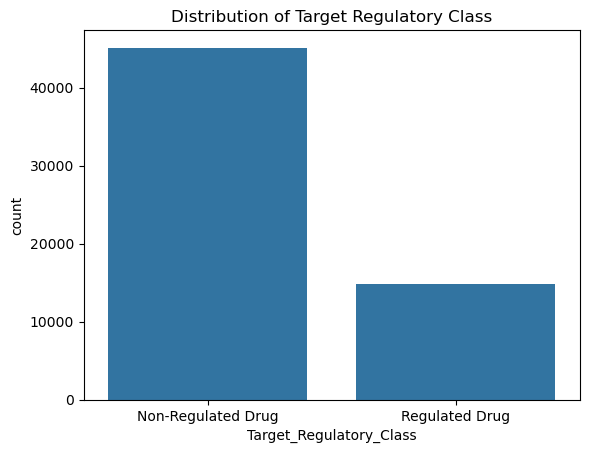

In [18]:
sns.countplot(x='Target_Regulatory_Class', data=data)
plt.xticks()
plt.title("Distribution of Target Regulatory Class")
plt.show()

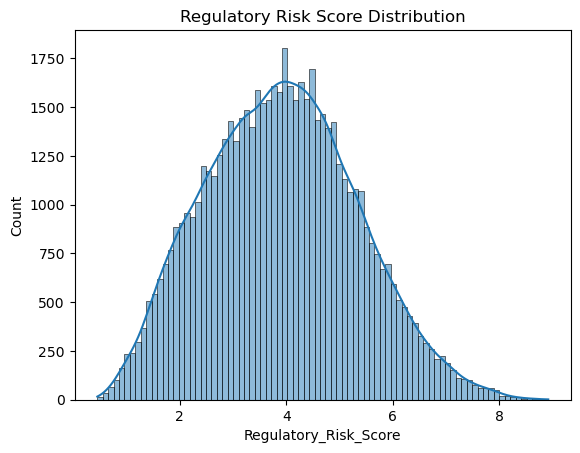

In [19]:
sns.histplot(data['Regulatory_Risk_Score'], kde=True)
plt.title("Regulatory Risk Score Distribution")
plt.show()

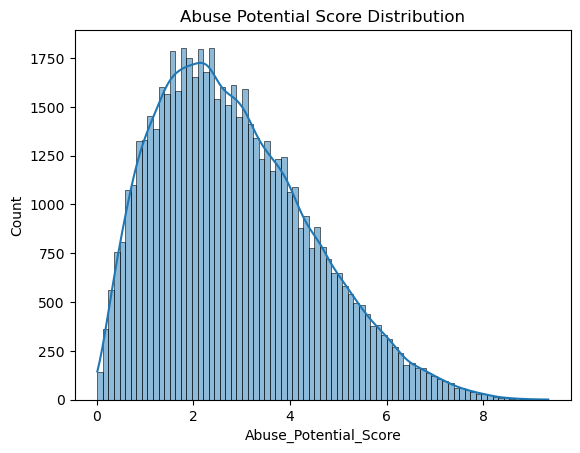

In [20]:
sns.histplot(data['Abuse_Potential_Score'], kde=True)
plt.title("Abuse Potential Score Distribution")
plt.show()

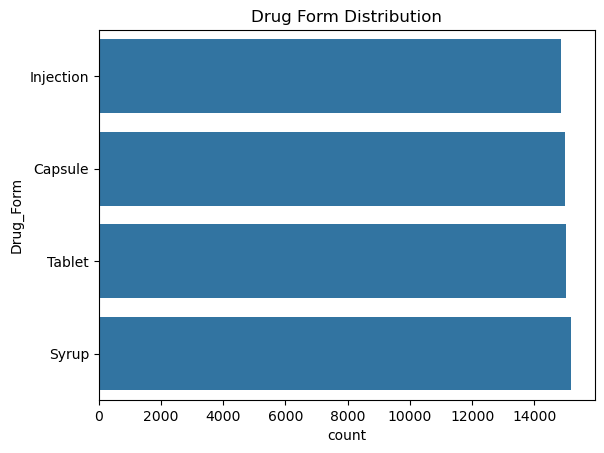

In [21]:
sns.countplot(y='Drug_Form', data=data)
plt.title("Drug Form Distribution")
plt.show()

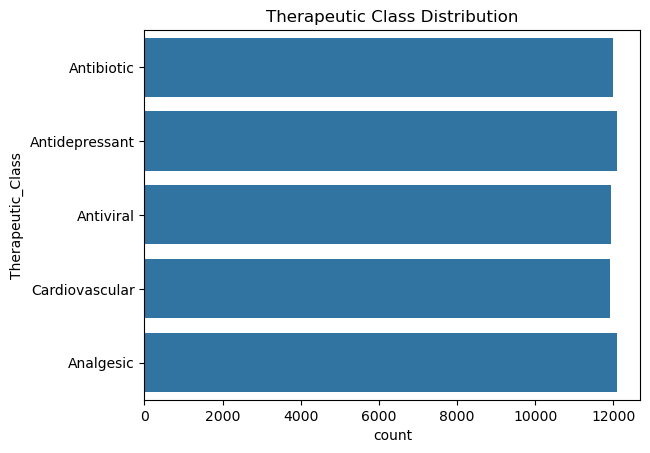

In [22]:
sns.countplot(y='Therapeutic_Class', data=data)
plt.title("Therapeutic Class Distribution")
plt.show()


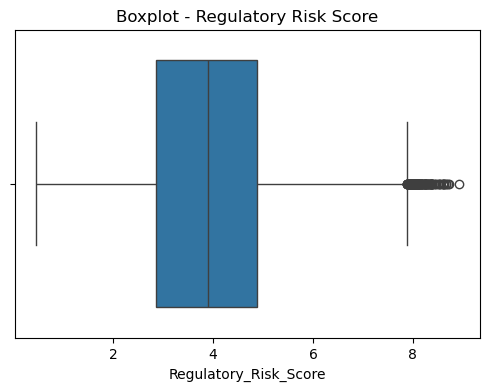

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(x=data['Regulatory_Risk_Score'])
plt.title("Boxplot - Regulatory Risk Score")
plt.show()


<h4>Step 6: Separate Features and Target</h4>

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler,MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from feature_engine.outliers import Winsorizer
import joblib

In [25]:
x = data.iloc[:, :-1]
y = data.iloc[:, 29:]

In [26]:
x

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Therapeutic_Class,Manufacturing_Region,Requires_Cold_Storage,OTC_Flag,High_Risk_Substance,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate
0,250,364.22,246.49,159132.53,3,4.26,2.52,0.74,57.93,42.07,...,Antibiotic,South,No,No,No,64.46,41.88,41.15,6.56,0.47
1,500,112.86,73.22,260595.45,2,8.12,1.80,0.48,48.00,52.00,...,Antidepressant,East,Yes,Yes,No,93.37,10.30,50.05,4.01,0.44
2,200,197.24,100.72,106818.45,3,1.58,1.47,0.93,54.48,45.52,...,Antiviral,North,Yes,Yes,No,64.53,34.21,46.42,5.95,0.16
3,500,373.55,264.76,231304.59,4,1.72,1.61,0.54,47.20,52.80,...,Cardiovascular,North,No,Yes,No,95.21,71.04,49.52,9.65,0.76
4,500,353.87,277.29,319403.02,2,9.64,0.45,0.50,86.96,13.04,...,Antidepressant,North,No,Yes,No,98.05,70.28,44.90,1.79,0.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,200,260.68,167.61,337160.40,2,6.04,2.79,0.92,67.01,32.99,...,Antibiotic,East,Yes,No,No,60.31,73.67,25.44,2.97,0.95
59996,200,249.67,139.19,457366.23,2,8.51,1.94,0.86,50.66,49.34,...,Antiviral,South,Yes,No,No,31.87,38.08,56.10,6.75,0.91
59997,100,155.15,78.35,367705.08,4,6.45,2.36,0.85,26.03,73.97,...,Antidepressant,South,Yes,Yes,No,35.96,19.06,25.10,9.75,0.60
59998,500,42.46,19.05,259954.00,1,6.98,2.29,0.16,39.96,60.04,...,Antiviral,North,No,Yes,No,67.17,57.80,28.23,3.00,0.39


In [27]:
y

,Target_Regulatory_Class
0,Non-Regulated Drug
1,Non-Regulated Drug
2,Non-Regulated Drug
3,Non-Regulated Drug
4,Non-Regulated Drug
...,...
59995,Regulated Drug
59996,Regulated Drug
59997,Non-Regulated Drug
59998,Regulated Drug


<h4>Step 7: Create Preprocessing Pipelines</h4>

In [28]:
numeric_features = x.select_dtypes(include=['int64','float64']).columns
categorical_features = x.select_dtypes(include=['object','bool']).columns

print(numeric_features)
print(categorical_features)

Index(['Dosage_mg', 'Price_Per_Unit', 'Production_Cost', 'Marketing_Spend',
       'Clinical_Trial_Phase', 'Side_Effect_Severity_Score',
       'Abuse_Potential_Score', 'Prescription_Rate',
       'Hospital_Distribution_Percentage', 'Pharmacy_Distribution_Percentage',
       'Annual_Sales_Volume', 'Regulatory_Risk_Score', 'Approval_Time_Months',
       'Patent_Duration_Years', 'R&D_Investment_Million', 'Competitor_Count',
       'Recall_History_Count', 'Adverse_Event_Reports',
       'Insurance_Coverage_Percentage', 'Export_Percentage',
       'Online_Sales_Percentage', 'Brand_Reputation_Score',
       'Doctor_Recommendation_Rate'],
      dtype='object')
Index(['Drug_Form', 'Therapeutic_Class', 'Manufacturing_Region',
       'Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance'],
      dtype='object')


In [29]:
# Numerical pipeline
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('winsorize', Winsorizer(capping_method='iqr', tail='both', fold=1.5)),
    ('scale', MinMaxScaler())
])

# Categorical pipeline
categ_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder( drop='first'))
])

In [30]:
preprocess_pipeline = ColumnTransformer([
    ('numerical', num_pipeline, numeric_features),
    ('categorical', categ_pipeline, categorical_features)
])

In [31]:
joblib.dump(preprocess_pipeline,'preprocessed_pipeline.pkl')

['preprocessed_pipeline.pkl']

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

<h4>Step 8: Train-Test Split</h4>

In [33]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [34]:
logistic_pipeline = Pipeline(steps=[
    ('preprocessing',preprocess_pipeline),
    ('classifier',LogisticRegression())
])

<h4>Step 9: Apply Logistic Regression</h4>

In [35]:
logistic_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsorize',
                                                                   Winsorizer(capping_method='iqr',
                                                                              fold=1.5,
                                                                              tail='both')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  Index(['Dosage_mg', 'Price_Per_Unit', 'Production_Cost', 'Marketing_Spend',
       'Clinical_Trial_Phase', 'Side_Effect_Severity_...
       'Online_Sales_Percentage', 'Brand_Reputation_Score',
       'Doctor_Recommendation_Rate'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Drug_Form', 'Therapeutic_Class', 'Manufacturing_Region',
       'Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance'],
      dtype='object'))])),
                ('classifier', LogisticRegression())])

In [36]:
y_pred = logistic_pipeline.predict(x_test)

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [38]:
print(accuracy_score(y_test,y_pred))

0.7864166666666667


In [39]:
print(classification_report(y_test,y_pred))

                    precision    recall  f1-score   support

Non-Regulated Drug       0.81      0.94      0.87      8964
    Regulated Drug       0.65      0.35      0.45      3036

          accuracy                           0.79     12000
         macro avg       0.73      0.64      0.66     12000
      weighted avg       0.77      0.79      0.76     12000



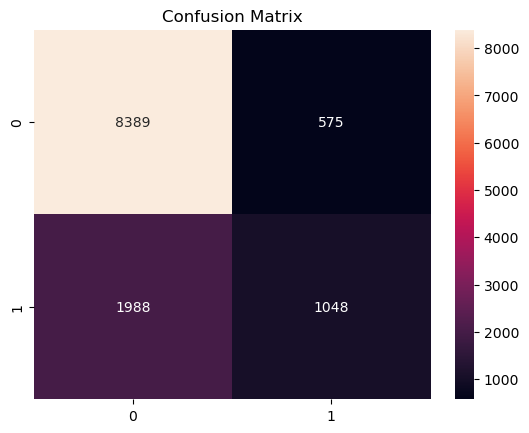

In [40]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

<h4>Step 10: Apply KNN</h4>

In [41]:
from sklearn.neighbors import KNeighborsClassifier

In [42]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [43]:
knn_pipeline = Pipeline(steps=[
    ('preprocessing', preprocess_pipeline),
    ('calssifier', KNeighborsClassifier(n_neighbors=5))
])

In [44]:
knn_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsorize',
                                                                   Winsorizer(capping_method='iqr',
                                                                              fold=1.5,
                                                                              tail='both')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  Index(['Dosage_mg', 'Price_Per_Unit', 'Production_Cost', 'Marketing_Spend',
       'Clinical_Trial_Phase', 'Side_Effect_Severity_...
       'Online_Sales_Percentage', 'Brand_Reputation_Score',
       'Doctor_Recommendation_Rate'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Drug_Form', 'Therapeutic_Class', 'Manufacturing_Region',
       'Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance'],
      dtype='object'))])),
                ('calssifier', KNeighborsClassifier())])

In [45]:
y_pred_knn = knn_pipeline.predict(x_test)

In [46]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("KNN Accuracy:",accuracy_score(y_test,y_pred_knn))

KNN Accuracy: 0.7398333333333333


In [47]:
print (classification_report(y_test, y_pred_knn))

                    precision    recall  f1-score   support

Non-Regulated Drug       0.78      0.92      0.84      8964
    Regulated Drug       0.47      0.22      0.30      3036

          accuracy                           0.74     12000
         macro avg       0.62      0.57      0.57     12000
      weighted avg       0.70      0.74      0.70     12000



<h4>Step 11: Apply SVM</h4>

In [48]:
from sklearn.svm import SVC

In [49]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [50]:
svm_pipeline = Pipeline([
    ('preprocess', preprocess_pipeline),
    ('model',SVC(kernel='rbf', C=1.0, gamma='scale'))
])

In [51]:
svm_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsorize',
                                                                   Winsorizer(capping_method='iqr',
                                                                              fold=1.5,
                                                                              tail='both')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  Index(['Dosage_mg', 'Price_Per_Unit', 'Production_Cost', 'Marketing_Spend',
       'Clinical_Trial_Phase', 'Side_Effect_Severity_Sco...
       'Online_Sales_Percentage', 'Brand_Reputation_Score',
       'Doctor_Recommendation_Rate'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Drug_Form', 'Therapeutic_Class', 'Manufacturing_Region',
       'Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance'],
      dtype='object'))])),
                ('model', SVC())])

In [52]:
print(accuracy_score(y_test,y_pred))

0.7864166666666667


In [53]:
print(confusion_matrix(y_test,y_pred))

[[8389  575]
 [1988 1048]]


In [54]:
print(classification_report(y_test,y_pred))

                    precision    recall  f1-score   support

Non-Regulated Drug       0.81      0.94      0.87      8964
    Regulated Drug       0.65      0.35      0.45      3036

          accuracy                           0.79     12000
         macro avg       0.73      0.64      0.66     12000
      weighted avg       0.77      0.79      0.76     12000



In [55]:
joblib.dump(svm_pipeline,'svm_model.pkl')

['svm_model.pkl']

<h4>Step 12: Apply Decision Tree</h4>

In [56]:
from sklearn.tree import DecisionTreeClassifier

In [57]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [58]:
dt_pipeline = Pipeline([
    ('preprocess', preprocess_pipeline),
    ('model', DecisionTreeClassifier(criterion='gini',max_depth=None))
])

In [59]:
dt_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsorize',
                                                                   Winsorizer(capping_method='iqr',
                                                                              fold=1.5,
                                                                              tail='both')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  Index(['Dosage_mg', 'Price_Per_Unit', 'Production_Cost', 'Marketing_Spend',
       'Clinical_Trial_Phase', 'Side_Effect_Severity_Sco...
       'Online_Sales_Percentage', 'Brand_Reputation_Score',
       'Doctor_Recommendation_Rate'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Drug_Form', 'Therapeutic_Class', 'Manufacturing_Region',
       'Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance'],
      dtype='object'))])),
                ('model', DecisionTreeClassifier())])

In [60]:
y_pred = dt_pipeline.predict(x_test)

In [61]:
print(accuracy_score(y_test,y_pred))

0.6915


In [62]:
print(confusion_matrix(y_test,y_pred))

[[7044 1920]
 [1782 1254]]


In [63]:
print(classification_report(y_test,y_pred))

                    precision    recall  f1-score   support

Non-Regulated Drug       0.80      0.79      0.79      8964
    Regulated Drug       0.40      0.41      0.40      3036

          accuracy                           0.69     12000
         macro avg       0.60      0.60      0.60     12000
      weighted avg       0.70      0.69      0.69     12000



In [64]:
joblib.dump(dt_pipeline,'decision_tree_model.pkl')

['decision_tree_model.pkl']

<h4>Step 13: Apply PCA</h4>

In [65]:
from sklearn.decomposition import PCA

In [66]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

pca_pipeline = Pipeline([
    ('preprocess', preprocess_pipeline),
    ('pca', PCA(n_components=0.95)),
    ('model', KNeighborsClassifier())
])

In [68]:
pca_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsorize',
                                                                   Winsorizer(capping_method='iqr',
                                                                              fold=1.5,
                                                                              tail='both')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  Index(['Dosage_mg', 'Price_Per_Unit', 'Production_Cost', 'Marketing_Spend',
       'Clinical_Trial_Phase', 'Side_Effect_Severity_Sco...
       'Doctor_Recommendation_Rate'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Drug_Form', 'Therapeutic_Class', 'Manufacturing_Region',
       'Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance'],
      dtype='object'))])),
                ('pca', PCA(n_components=0.95)),
                ('model', KNeighborsClassifier())])

In [69]:
y_pred = pca_pipeline.predict(x_test)

In [70]:
print(accuracy_score(y_test,y_pred))

0.7393333333333333


In [71]:
print(confusion_matrix(y_test,y_pred))

[[8219  745]
 [2383  653]]


In [72]:
print(classification_report(y_test,y_pred))

                    precision    recall  f1-score   support

Non-Regulated Drug       0.78      0.92      0.84      8964
    Regulated Drug       0.47      0.22      0.29      3036

          accuracy                           0.74     12000
         macro avg       0.62      0.57      0.57     12000
      weighted avg       0.70      0.74      0.70     12000



In [73]:
joblib.dump(pca_pipeline,'Pca_model.pkl')

['Pca_model.pkl']

<h4>Step 14: Save Model</h4>

In [74]:
import joblib
joblib.dump(svm_pipeline, 'model.pkl')

['model.pkl']